# Classificação de Texto com Processamento de Linguagem Natural (NLP)

Este notebook tem como objetivo apresentar um fluxo completo de Processamento de Linguagem Natural (NLP) aplicado a um problema de classificação de textos, seguindo uma abordagem clássica de Machine Learning.

## Objetivos
* Entender o que é NLP e classificação de texto
* Aplicar Bag of Words (BoW) e TF-IDF para representar textos
* Comparar diferentes modelos de classificação
* Utilizar pipelines e validação cruzada
* Avaliar modelos
* Gerar visualizações

## Introdução ao Processamento de Linguagem Natural
Processamento de Linguagem Natural (NLP) é uma área da Inteligência Artificial que estuda como computadores podem analisar, entender e extrair informações de textos escritos em linguagem humana.

Diferente de dados tabulares (números organizados em colunas), textos são dados não estruturados. Por isso, precisamos transformá-los em números antes de aplicar algoritmos de aprendizado de máquina.

Neste notebook, resolveremos um problema clássico:
  **Dado um texto, identificar a qual categoria ele pertence.**

## Dataset: IMDB reviews
Utilizamos o dataset IMDB reviews, que é um conjunto de dados de resenhas de filmes da IMDb com traduções para o português.

O objetivo principal do dataset é permitir experimentos em classificação de sentimento binária (positivo ou negativo), especialmente em cenários multilíngues ou cross-lingual, como comparação de desempenho entre idiomas ou treinamento de modelos em português a partir de dados originalmente em inglês.

**Estrutura do dataset**
49.459 amostras
**Colunas**
- id: identificador único da amostra
- text_en: texto da resenha em inglês
- text_pt: texto da resenha traduzido para português
- sentiment: rótulo de sentimento (pos ou neg)

## Importação das bibliotecas

In [250]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import time
from sklearn.model_selection import StratifiedShuffleSplit

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

## Carregamento e exploração dos dados

In [251]:
df = pd.read_csv('../../data/imdb-reviews-pt-br.csv')
df.head(10)

,id,text_en,text_pt,sentiment
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg
5,6,"A funny thing happened to me while watching ""M...",Uma coisa engraçada aconteceu comigo enquanto ...,neg
6,7,This German horror film has to be one of the w...,Este filme de terror alemão tem que ser um dos...,neg
7,8,"Being a long-time fan of Japanese film, I expe...","Sendo um fã de longa data do cinema japonês, e...",neg
8,9,"""Tokyo Eyes"" tells of a 17 year old Japanese g...","""Tokyo Eyes"" fala de uma menina japonesa de 17...",neg
9,10,Wealthy horse ranchers in Buenos Aires have a ...,Fazendeiros ricos em Buenos Aires têm uma long...,neg


In [252]:
df.columns

Index(['id', 'text_en', 'text_pt', 'sentiment'], dtype='object')

In [253]:
X = df['text_pt']
y = df['sentiment']

print(f"Quantidade de textos: {len(X)}")

Quantidade de textos: 49459


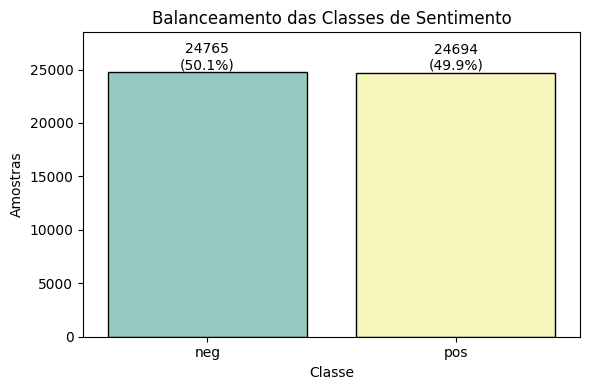

In [254]:
class_counts = y.value_counts().sort_index()
class_percent = y.value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette='Set3',
    legend=False,
    edgecolor='black'
)

for i, (count, pct) in enumerate(zip(class_counts.values, class_percent.values)):
    ax.text(
        i,
        count,
        f'{count}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
    )
    
ax.set_ylim(0, class_counts.max() * 1.15)
plt.title('Balanceamento das Classes de Sentimento')
plt.xlabel('Classe')
plt.ylabel('Amostras')
plt.tight_layout()
plt.show()

### Exemplo de texto

In [255]:
print(X[11][:1000])

Primeiro de tudo, eu gostaria de dizer que sou fã de todos os atores que aparecem neste filme e na época que eu aluguei, eu queria gostar. Acho que a principal razão pela qual eu estava tão desapontado foi que o camarote exterior me prometeu um thriller de suspense. Aos meus olhos, um thriller de suspense para filmes britânicos é como algo saído de um romance de Ruth Rendell, algo que tem muitas mudanças e reviravoltas obscuras e deixa o espectador com um final que provavelmente não será esquecido tão cedo.Este filme começou com a nota promissora de ser tal filme. Nós temos o nosso personagem principal, que suspeita de um homem que ele não gosta, de estar envolvido em um ataque e execução que matou o marido de um de seus servos. Suas noções provam estar certas, mas a ideia de que sua esposa pode estar envolvida , não lhe ocorre até que ela confesse a ele que ela era uma parte do crime.Os elementos de um suspense de suspense bom estavam em lugar, neste momento, mas de lá, eu sentia que 

## Divisão em treino e teste

In [447]:
# holdout
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [448]:
print(len(X_train))

39567


In [449]:
print("\nPercentual das classes de treino:")
print(y_train.value_counts(normalize=True) * 100)


Percentual das classes de treino:
sentiment
neg    50.07203
pos    49.92797
Name: proportion, dtype: float64


In [450]:
def reduce_train_set(X, y, train_frac=0.5, random_state=42):
    splitter = StratifiedShuffleSplit(
        n_splits=1,
        train_size=train_frac,
        random_state=random_state
    )
    idx, _ = next(splitter.split(X, y))
    return X.iloc[idx], y.iloc[idx]

# Exemplo: usar 50% do treino
X_train_small, y_train_small = reduce_train_set(
    X_train, y_train, train_frac=0.5
)

In [451]:
X_train=X_train_small
y_train=y_train_small

In [452]:
print(len(X_train))

19783


In [453]:
print("\nPercentual das classes de treino após redução:")
print(y_train.value_counts(normalize=True) * 100)


Percentual das classes de treino após redução:
sentiment
neg    50.073295
pos    49.926705
Name: proportion, dtype: float64


## Stopwords

In [261]:
stopwords_pt = [
    # Artigos e contrações
    'a', 'o', 'as', 'os', 'um', 'uma', 'uns', 'umas', 'ao', 'aos', 'do', 'da', 'dos', 'das', 
    'no', 'na', 'nos', 'nas', 'pelo', 'pela', 'pelos', 'pelas',
    # Pronomes
    'eu', 'tu', 'ele', 'ela', 'nos', 'vos', 'eles', 'elas', 'me', 'te', 'se', 'lhe', 'lhes',
    # Preposicoes
    'de', 'em', 'por', 'para', 'com', 'sob', 'sobre', 'entre', 'ate', 'desde', 'contra', 
    'perante', 'atraves', 'alem', 'dentro', 'fora', 'perto', 'longe', 'durante',
    # Conjuncoes
    'e', 'ou', 'porque', 'pois', 'que', 'como', 'quando', 'embora', 'entao', 'tambem', 'caso', 
    'ainda', 'fim', 'objetivo',
    # Demonstrativos
    'aquele', 'aquela', 'aquilo', 'aqueles', 'aquelas', 'deste', 'desta', 'destes', 'destas', 
    'disso', 'daquilo', 'nisto', 'naquilo',
    # Localizadores
    'la', 'aqui', 'ali', 'onde', 'aonde',
]

# fonte: https://blog.trifenol.com/lista-completa-das-stop-words-em-portugues/

## Bag of Words (BoW)
No pipeline clássico de NLP (como visto em aula), antes de transformar o texto em números, normalmente aplicamos:

* limpeza (lowercase, remoção de pontuação)
* tokenização
* remoção de stopwords

No entanto, ao utilizar o CountVectorizer, muitas dessas etapas podem ser delegadas ao próprio vetorizador, que:

* converte para minúsculas automaticamente (lowercase=True)
* realiza tokenização básica
* permite remover stopwords

Isso torna o pipeline mais simples e reprodutível.

**Conceito**

Bag of Words transforma textos em vetores contando quantas vezes cada palavra aparece.
Cada documento vira um vetor numérico:
* Colunas = palavras do vocabulário
* Valores = frequência da palavra no texto

### Implementação com CountVectorizer
Pipeline 1 — Bag of Words

* Representação: Bag of Words (CountVectorizer)
* Classificadores: Naive Bayes, Logistic Regression e SVM Linear

In [262]:
classifiers = {
    'NaiveBayes': {
        'classifier': MultinomialNB(),
        'params': {
            'classifier__alpha': [0.5, 1.0],
        }
    },
    'LogisticRegression': {
        'classifier': LogisticRegression(max_iter=500, random_state=42, n_jobs=-1),
        'params': {
            'classifier__C': [0.1, 1.0],
            'classifier__class_weight': [None, 'balanced']
        }
    },
    'SVM': {
        'classifier': LinearSVC(max_iter=500, random_state=42),
        'params': {
            'classifier__C': [1.0, 10.0],
        }
    },
}

### Grid Search – Bag of Words

In [263]:
bow_params = {
    'vectorizer__stop_words': [None, stopwords_pt],
    # ngram_range controla o nível de contexto (unigramas ou bigramas)
    'vectorizer__ngram_range': [(1,1), (1,2)],
    # min_df remove termos muito raros (ruído)
    'vectorizer__min_df': [2, 5],
    # max_df remove termos muito frequentes ("stopwords implícitas")
    'vectorizer__max_df': [0.8, 0.9, 1.0],
    'vectorizer__max_features': [5000],
}

## TF-IDF
Assim como no Bag of Words, o TF-IDF também faz parte da etapa de representação vetorial do texto.
Todo o pipeline conceitual visto em aula pode ser resumido da seguinte forma:
Texto cru → limpeza → tokenização → remoção de stopwords → vetorização → classificador
No TfidfVectorizer, essas etapas iniciais são encapsuladas, permitindo que o foco fique na modelagem e avaliação.

**Conceito**

TF-IDF (Term Frequency – Inverse Document Frequency) ajusta o Bag of Words penalizando palavras muito frequentes no corpus.

Ideia central:
* Palavras comuns em todos os textos são menos informativas
* Palavras raras ganham mais peso

### Implementação com TfidfVectorizer
Pipeline 2 — TF-IDF

* Representação: TF-IDF (TfidfVectorizer)
* Classificador: Naive Bayes, Logistic Regression e SVM Linear

### Grid Search – TF-IDF

In [264]:
tfidf_params = {
    'vectorizer__stop_words': [None, stopwords_pt],
    # Controle de contexto (uni vs bi-gramas)
    'vectorizer__ngram_range': [(1,1), (1,2)],
    # Remoção de termos raros
    'vectorizer__min_df': [2, 5],
    # Remoção de termos muito frequentes
    'vectorizer__max_df': [0.8, 0.9, 1.0],
    # Redução do peso de repetições muito altas
    'vectorizer__sublinear_tf': [True, False],
    'vectorizer__max_features': [5000],
}

## Execução

In [ ]:
def run_experiment(vectorizer_name, vectorizer_class, vectorizer_base_params, 
                   classifier_name, classifier_obj, classifier_params, 
                   X_train, y_train, X_test, y_test):

    print(f"\nTreinando: {vectorizer_name} + {classifier_name}")
    
    pipeline = Pipeline([
        ('vectorizer', vectorizer_class),
        ('classifier', classifier_obj)
    ])
    
    # Combina parâmetros
    params = {**vectorizer_base_params, **classifier_params}
    
    grid = GridSearchCV(
        pipeline,
        params,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )
    
    start_time = time.time()
    grid.fit(X_train, y_train)
    elapsed_time = time.time() - start_time
    
    # teste
    y_pred = grid.best_estimator_.predict(X_test)
    
    metrics = {
        'vectorizer': vectorizer_name,
        'classifier': classifier_name,
        'best_cv_f1_macro': grid.best_score_,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1_macro': f1_score(y_test, y_pred, average='macro'),
        'test_precision_macro': precision_score(y_test, y_pred, average='macro'),
        'test_recall_macro': recall_score(y_test, y_pred, average='macro'),
        'train_time_seconds': elapsed_time,
        'best_params': str(grid.best_params_)
    }
    
    return metrics, grid

In [266]:
all_results = []
all_grids = {}

# BoW
for clf_name, clf_info in classifiers.items():
    metrics, grid = run_experiment(
        vectorizer_name='Bag of Words',
        vectorizer_class=CountVectorizer(),
        vectorizer_base_params=bow_params,
        classifier_name=clf_name,
        classifier_obj=clf_info['classifier'],
        classifier_params=clf_info['params'],
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )
    all_results.append(metrics)
    all_grids[f'BoW_{clf_name}'] = grid

# TF-IDF
for clf_name, clf_info in classifiers.items():
    metrics, grid = run_experiment(
        vectorizer_name='TF-IDF',
        vectorizer_class=TfidfVectorizer(),
        vectorizer_base_params=tfidf_params,
        classifier_name=clf_name,
        classifier_obj=clf_info['classifier'],
        classifier_params=clf_info['params'],
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )
    all_results.append(metrics)
    all_grids[f'TFIDF_{clf_name}'] = grid


Treinando: Bag of Words + NaiveBayes
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Treinando: Bag of Words + LogisticRegression
Fitting 5 folds for each of 96 candidates, totalling 480 fits

Treinando: Bag of Words + SVM
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Treinando: TF-IDF + NaiveBayes
Fitting 5 folds for each of 96 candidates, totalling 480 fits

Treinando: TF-IDF + LogisticRegression
Fitting 5 folds for each of 192 candidates, totalling 960 fits

Treinando: TF-IDF + SVM
Fitting 5 folds for each of 96 candidates, totalling 480 fits


## Avaliação dos modelos

### Análise de pré-processsamento

In [346]:
# texto exemplo
exemplo_texto = X_train.iloc[0]

print("Texto original:\n")
print(exemplo_texto[:500], "...\n")

# modelo já treinado
model_key = list(all_grids.keys())[1]
best_vectorizer = all_grids[model_key].best_estimator_.named_steps['vectorizer']
print(f"Modelo usado: {model_key}")

analyzer = best_vectorizer.build_analyzer()
tokens = analyzer(exemplo_texto)

print("Texto após pré-processamento:\n")
print(" ".join(f'"{token}"' for token in tokens[:50]), "...\n")

Texto original:

Eu acabei de assistir o final da segunda temporada de Doctor Who, e além de alguns episódios sem graça, esse show é fantástico. É uma triste perda termos de dizer adeus a um personagem principal mais uma vez na temporada final, mas o show continua. A BBC precisa aumentar o orçamento do programa, há tantas coisas que podem acontecer em Londres e nas áreas vizinhas. Também alguns dos efeitos especiais todos embora no principal muito bom, na ocasião ímpar precisa ser um pouco mais polido.Foi uma ap ...

Modelo usado: BoW_LogisticRegression
Texto após pré-processamento:

"acabei" "assistir" "final" "segunda" "temporada" "doctor" "who" "além" "alguns" "episódios" "sem" "graça" "esse" "show" "fantástico" "triste" "perda" "termos" "dizer" "adeus" "personagem" "principal" "mais" "vez" "temporada" "final" "mas" "show" "continua" "bbc" "precisa" "aumentar" "orçamento" "programa" "há" "tantas" "coisas" "podem" "acontecer" "londres" "áreas" "vizinhas" "também" "alguns" "efeitos" "

In [298]:
# DataFrame com todos os resultados
results_df = pd.DataFrame(all_results)

### Análise Bag of Words

In [427]:
bow_df = results_df[results_df['vectorizer'] == 'Bag of Words']

display(
    bow_df[
        [
            'classifier',
            'best_cv_f1_macro',
            'test_accuracy',
            'test_f1_macro',
            'test_precision_macro',
            'test_recall_macro',
            'train_time_seconds'
        ]
    ].round(5)
)

,classifier,best_cv_f1_macro,test_accuracy,test_f1_macro,test_precision_macro,test_recall_macro,train_time_seconds
2,SVM,0.82565,0.82430,0.82430,0.82431,0.82430,1868.57590
0,NaiveBayes,0.85273,0.84796,0.84792,0.84831,0.84798,477.68560
1,LogisticRegression,0.87074,0.87070,0.87070,0.87077,0.87071,1225.10851


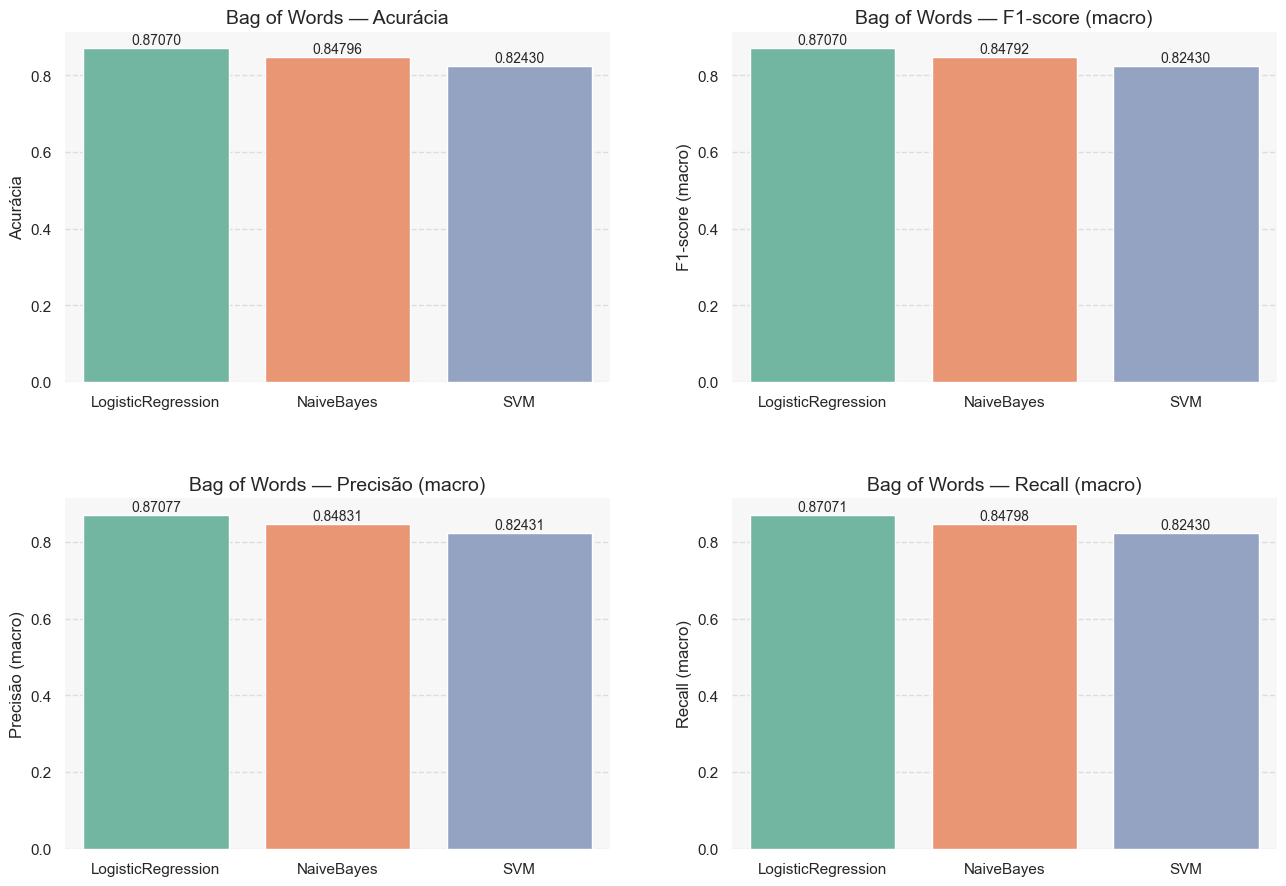

In [ ]:
# métricas
metrics = [
    ('test_accuracy', 'Acurácia'),
    ('test_f1_macro', 'F1-score (macro)'),
    ('test_precision_macro', 'Precisão (macro)'),
    ('test_recall_macro', 'Recall (macro)')
]

# Cria subplots 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (metric, metric_name) in zip(axes, metrics):
    
    # ordena por métrica
    df_plot = bow_df.sort_values(metric, ascending=False)
    
    # fundo do eixo
    ax.set_facecolor('#f7f7f7')
    
    # barras verticais
    sns.barplot(
        data=df_plot,
        x='classifier',
        y=metric,
        palette='Set2',
        hue='classifier',
        ax=ax,
        dodge=False
    )
    
    # valores no topo das barras
    for i, v in enumerate(df_plot[metric]):
        ax.text(i, v + 0.002, f"{v:.5f}", ha='center', va='bottom', fontsize=10)
    
    ax.set_title(f"Bag of Words — {metric_name}", fontsize=14)
    ax.set_ylabel(metric_name)
    ax.set_xlabel("")
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    sns.despine(left=True, bottom=True)

plt.tight_layout(pad=4.0)
plt.show()

### Análise TF-IDF

In [434]:
tfidf_df = results_df[results_df['vectorizer'] == 'TF-IDF']

display(
    tfidf_df[
        [
            'classifier',
            'best_cv_f1_macro',
            'test_accuracy',
            'test_f1_macro',
            'test_precision_macro',
            'test_recall_macro',
            'train_time_seconds'
        ]
    ].round(5)
)

,classifier,best_cv_f1_macro,test_accuracy,test_f1_macro,test_precision_macro,test_recall_macro,train_time_seconds
3,NaiveBayes,0.85881,0.85665,0.85662,0.85701,0.85667,1392.74591
5,SVM,0.86912,0.86808,0.86807,0.86812,0.86808,1033.35500
4,LogisticRegression,0.88241,0.87899,0.87897,0.87930,0.87901,2001.79493


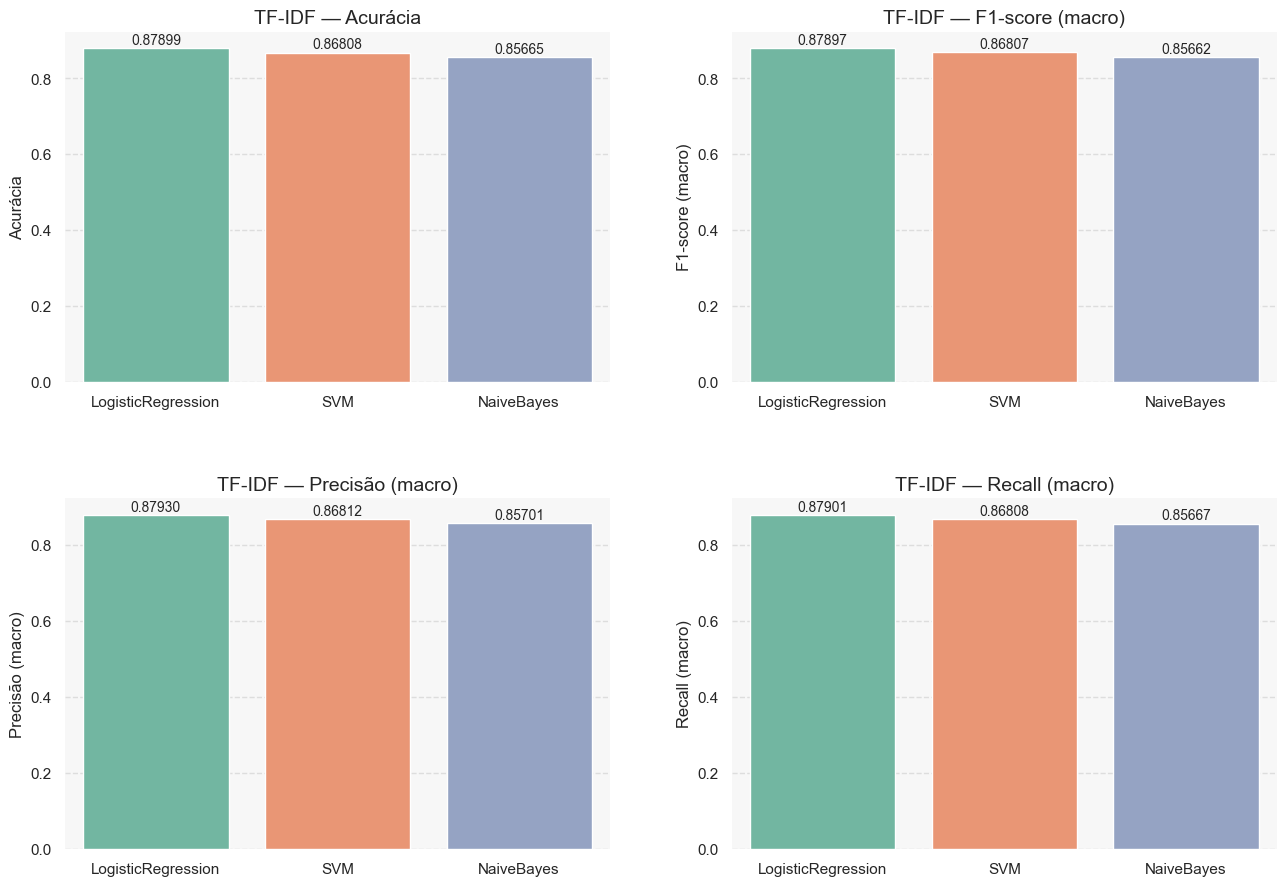

In [ ]:
# Cria subplots 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (metric, metric_name) in zip(axes, metrics):
    
    # ordena por métrica
    df_plot = tfidf_df.sort_values(metric, ascending=False)
    
    # fundo do eixo
    ax.set_facecolor('#f7f7f7')
    
    # barras verticais
    sns.barplot(
        data=df_plot,
        x='classifier',
        y=metric,
        palette='Set2',
        hue='classifier',
        ax=ax,
        dodge=False
    )
    
    # valores no topo das barras
    for i, v in enumerate(df_plot[metric]):
        ax.text(i, v + 0.002, f"{v:.5f}", ha='center', va='bottom', fontsize=10)
    
    ax.set_title(f"TF-IDF — {metric_name}", fontsize=14)
    ax.set_ylabel(metric_name)
    ax.set_xlabel("")
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    sns.despine(left=True, bottom=True)

plt.tight_layout(pad=4.0)
plt.show()

### Comparação BoW × TF-IDF (melhores modelos)

In [458]:
best_bow = bow_df.loc[bow_df['test_f1_macro'].idxmax()]
best_tfidf = tfidf_df.loc[tfidf_df['test_f1_macro'].idxmax()]

comparison_df = pd.DataFrame([best_bow, best_tfidf])
display(
    comparison_df[[
            'vectorizer',
            'classifier',
            'test_accuracy',
            'test_f1_macro',
            'test_precision_macro',
            'test_recall_macro',
        ]]
    .round(5)
)

,vectorizer,classifier,test_accuracy,test_f1_macro,test_precision_macro,test_recall_macro
1,Bag of Words,LogisticRegression,0.87070,0.87070,0.87077,0.87071
4,TF-IDF,LogisticRegression,0.87899,0.87897,0.87930,0.87901


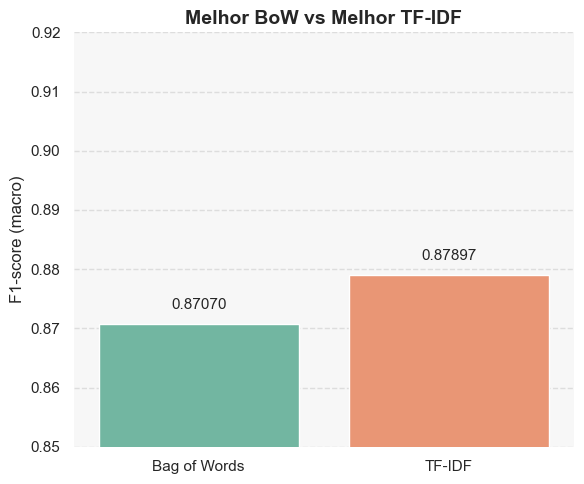

In [439]:
plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=comparison_df,
    x='vectorizer',
    y='test_f1_macro',
    palette='Set2',
    hue='vectorizer',
)

# Adicionar valores no topo das barras
for i, v in enumerate(comparison_df['test_f1_macro']):
    ax.text(i, v + 0.002, f"{v:.5f}", ha='center', va='bottom', fontsize=11)

# Estilo do gráfico
ax.set_ylabel("F1-score (macro)", fontsize=12)
ax.set_xlabel("")
ax.set_title("Melhor BoW vs Melhor TF-IDF", fontsize=14, fontweight='bold')
ax.set_ylim(0.85, 0.92)
ax.set_facecolor('#f7f7f7')
ax.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [345]:
table_df = results_df.copy()

table_df['Combinação'] = (
    table_df['vectorizer'] + ' + ' + table_df['classifier']
)

table_df = table_df[
    [
        'Combinação',
        'test_accuracy',
        'test_f1_macro',
        'test_precision_macro',
        'test_recall_macro',
        'best_params'
    ]
].rename(columns={
    'test_accuracy': 'Acurácia',
    'test_f1_macro': 'F1-Macro',
    'test_precision_macro': 'Precisão (Macro)',
    'test_recall_macro': 'Recall (Macro)',
    'best_params': 'Melhores Parâmetros'
})

for col in ['Acurácia', 'F1-Macro', 'Precisão (Macro)', 'Recall (Macro)']:
    table_df[col] = (table_df[col] * 100).round(2).astype(str) + '%'

table_df = table_df.sort_values('F1-Macro', ascending=False)

display(table_df)

,Combinação,Acurácia,F1-Macro,Precisão (Macro),Recall (Macro),Melhores Parâmetros
4,TF-IDF + LogisticRegression,87.9%,87.9%,87.93%,87.9%,"{'classifier__C': 1.0, 'classifier__class_weig..."
1,Bag of Words + LogisticRegression,87.07%,87.07%,87.08%,87.07%,"{'classifier__C': 0.1, 'classifier__class_weig..."
5,TF-IDF + SVM,86.81%,86.81%,86.81%,86.81%,"{'classifier__C': 1.0, 'vectorizer__max_df': 0..."
3,TF-IDF + NaiveBayes,85.67%,85.66%,85.7%,85.67%,"{'classifier__alpha': 1.0, 'vectorizer__max_df..."
0,Bag of Words + NaiveBayes,84.8%,84.79%,84.83%,84.8%,"{'classifier__alpha': 1.0, 'vectorizer__max_df..."
2,Bag of Words + SVM,82.43%,82.43%,82.43%,82.43%,"{'classifier__C': 1.0, 'vectorizer__max_df': 0..."


## Visualização dos resultados

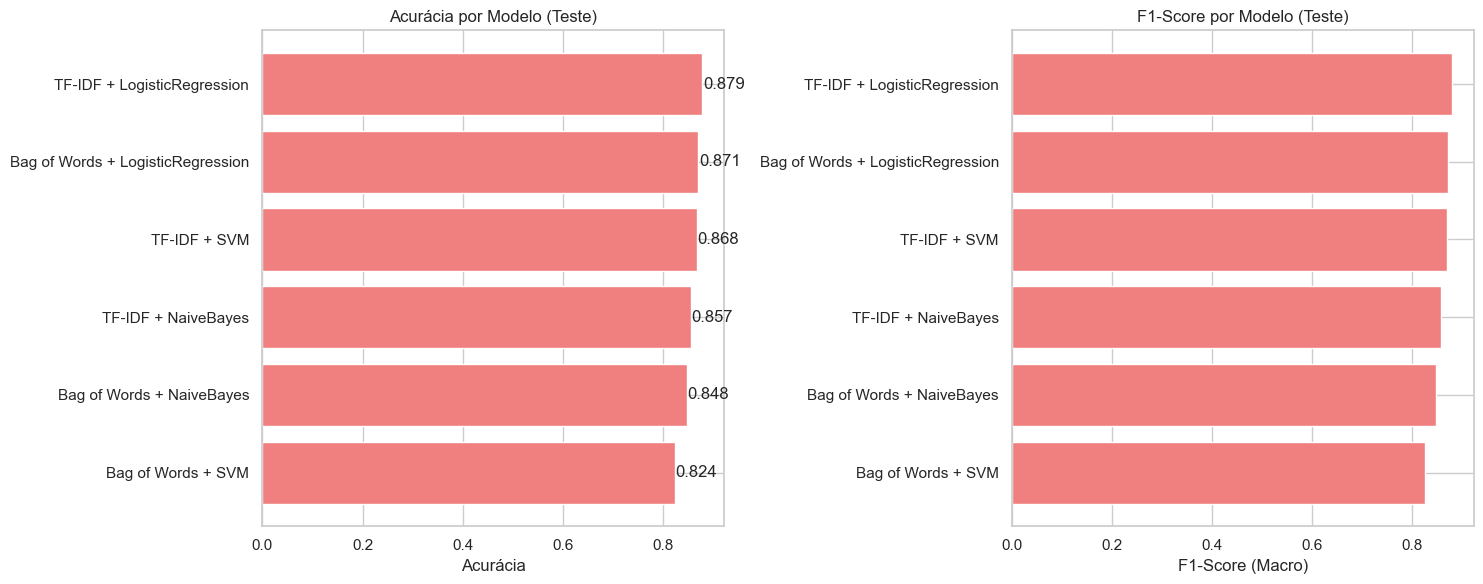

In [456]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
results_df = results_df.sort_values('test_f1_macro')

# Gráfico 1: Acurácia por combinação
axes[0].barh(
    range(len(results_df)),
    results_df['test_accuracy'],
    color=['skyblue' if 'BoW' in x else 'lightcoral'
           for x in results_df['vectorizer']]
)
axes[0].set_yticks(range(len(results_df)))
axes[0].set_yticklabels([
    f"{r['vectorizer']} + {r['classifier']}"
    for _, r in results_df.iterrows()
])
axes[0].set_xlabel('Acurácia')
axes[0].set_title('Acurácia por Modelo (Teste)')

# Adicionar valores
for i, v in enumerate(results_df['test_accuracy']):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center')

# Gráfico 2: F1-Score por combinação
axes[1].barh(
    range(len(results_df)),
    results_df['test_f1_macro'],
    color=['skyblue' if 'BoW' in x else 'lightcoral'
           for x in results_df['vectorizer']]
)
axes[1].set_yticks(range(len(results_df)))
axes[1].set_yticklabels([
    f"{r['vectorizer']} + {r['classifier']}"
    for _, r in results_df.iterrows()
])
axes[1].set_xlabel('F1-Score (Macro)')
axes[1].set_title('F1-Score por Modelo (Teste)')

# Melhorar layout
plt.tight_layout()
plt.show()

## Visualizações extras

### Núvem de palavras
Em vez de frequência, usamos importância aprendida pelo classificador.

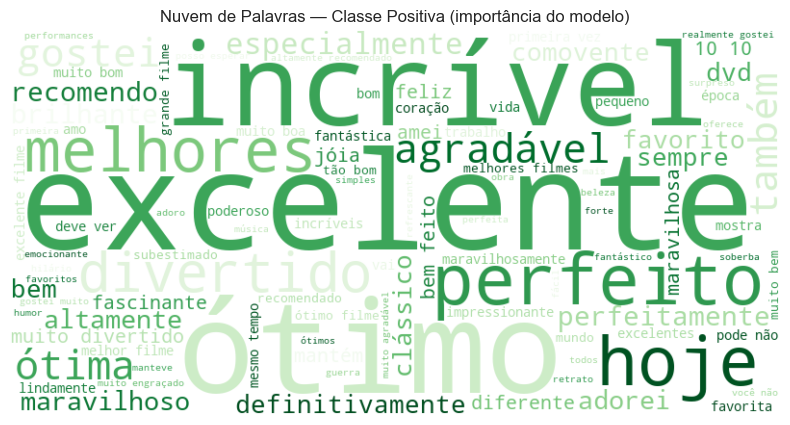

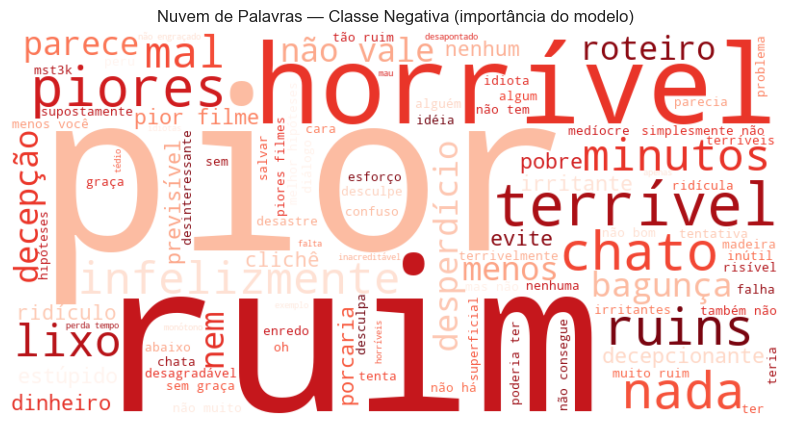

In [ ]:
best_model = all_grids['TFIDF_LogisticRegression'].best_estimator_

vectorizer = best_model.named_steps['vectorizer']
classifier = best_model.named_steps['classifier']

feature_names = np.array(vectorizer.get_feature_names_out())
coef = classifier.coef_[0]  # binário

top_n = 15
top_n = 100
top_pos_idx = np.argsort(coef)[-top_n:]

freq_pos = {
    feature_names[i]: coef[i]
    for i in top_pos_idx
}

wc_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens'
).generate_from_frequencies(freq_pos)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Nuvem de Palavras — Classe Positiva (importância do modelo)")
plt.show()

top_neg_idx = np.argsort(coef)[:top_n]

freq_neg = {
    feature_names[i]: abs(coef[i])
    for i in top_neg_idx
}

wc_neg = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'
).generate_from_frequencies(freq_neg)

plt.figure(figsize=(10,5))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Nuvem de Palavras — Classe Negativa (importância do modelo)")
plt.show()

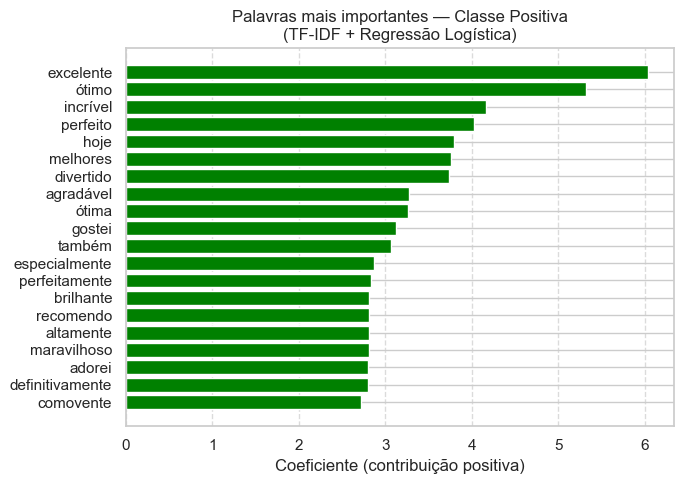

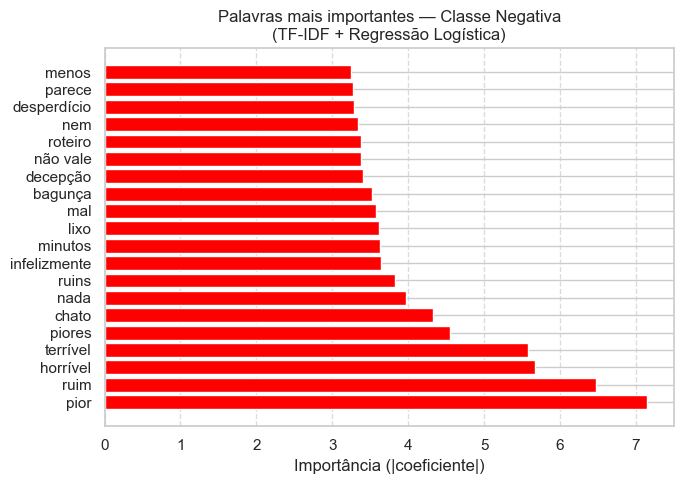

In [455]:
# Top palavras positivas
top_positive_idx = np.argsort(coef)[-top_n:]

plt.figure(figsize=(7,5))
plt.barh(
    feature_names[top_positive_idx],
    coef[top_positive_idx],
    color='green'
)
plt.xlabel("Coeficiente (contribuição positiva)")
plt.title("Palavras mais importantes — Classe Positiva\n(TF-IDF + Regressão Logística)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Top palavras negativas
top_negative_idx = np.argsort(coef)[:top_n]

plt.figure(figsize=(7,5))
plt.barh(
    feature_names[top_negative_idx],
    np.abs(coef[top_negative_idx]),
    color='red'
)
plt.xlabel("Importância (|coeficiente|)")
plt.title("Palavras mais importantes — Classe Negativa\n(TF-IDF + Regressão Logística)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Análise de Erros

In [392]:
best_model = all_grids['TFIDF_LogisticRegression'].best_estimator_

vectorizer = best_model.named_steps['vectorizer']
classifier = best_model.named_steps['classifier']

y_pred = best_model.predict(X_test)

df_erros = pd.DataFrame({
    'text_pt': X_test.reset_index(drop=True),
    'y_real': y_test.reset_index(drop=True),
    'y_pred': y_pred
})

df_erros = df_erros[df_erros['y_real'] != df_erros['y_pred']]

In [393]:
feature_names = np.array(vectorizer.get_feature_names_out())
coef = classifier.coef_[0]  # binário

def termos_importantes_texto(texto, top_n=5):
    vec = vectorizer.transform([texto])
    
    # contribuição = tfidf * coef
    contrib = vec.toarray()[0] * coef
    
    idx = np.argsort(np.abs(contrib))[-top_n:]
    
    termos = [
        f"{feature_names[i]} ({contrib[i]:+.3f})"
        for i in idx if vec.toarray()[0][i] > 0
    ]
    
    return ", ".join(termos)


In [395]:
df_erros['termos_mais_importantes'] = df_erros['text_pt'].apply(
    lambda x: termos_importantes_texto(x, top_n=5)
)

df_erros.head(10)

text_pt  \
5                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  O líder norte-americano Guy Madison interpreta um personagem cuja notoriedade o precede neste Spaghetti Western? que, tendo credenciais muito modestas, surge como essencialmente rotineiro, embora com uma pontuação boa o suficiente. O enredo oferece algum interesse moderado: